# Analyse non supervisée
## Clusterisation avec DBScan

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
import mlflow
import mlflow.sklearn
from pathlib import Path
from constants import CANCER, NORMAL, DATA_DIR, PREPARED_DIR, FEATURES_DIR, WITHOUT_LABEL, WITH_LABEL, WEAK_LABELS
from visualization import plot_labeled_comparison, plot_unlabeled_clusters

In [2]:
import mlflow

# On démarre une expérience
mlflow.set_experiment("clustering-dbscan")

RANDOM_STATE = 42
N_COMPONENTS_PCA = 10
ALGORITHM = "DBSCAN"
DBSCAN_EPS = 0.6
DBSCAN_MIN_SAMPLES = 5
DBSCAN_METRIC = "euclidean"

2026/01/06 10:20:33 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Chargement des features...

Données labellisées: (100, 2048)
Labels: (100,)
Données unlabeled: (1406, 2048)

Standardisation des features...

Réduction de dimensionnalité avec PCA...
Variance expliquée (10 composantes): 53.67%
PCA 2D pour visualisation...

=== CLUSTERING DBSCAN ===

Clustering sur données labellisées...
Score ARI (données labellisées): 0.000
Répartition clusters labellisés: {np.int64(-1): np.int64(100)}
Nombre de clusters (hors bruit): 0
Ratio de bruit: 100.00%

Clustering sur données unlabeled...
Répartition clusters unlabeled: {np.int64(-1): np.int64(1406)}
Nombre de clusters (hors bruit): 0
Ratio de bruit: 100.00%

Génération des visualisations...


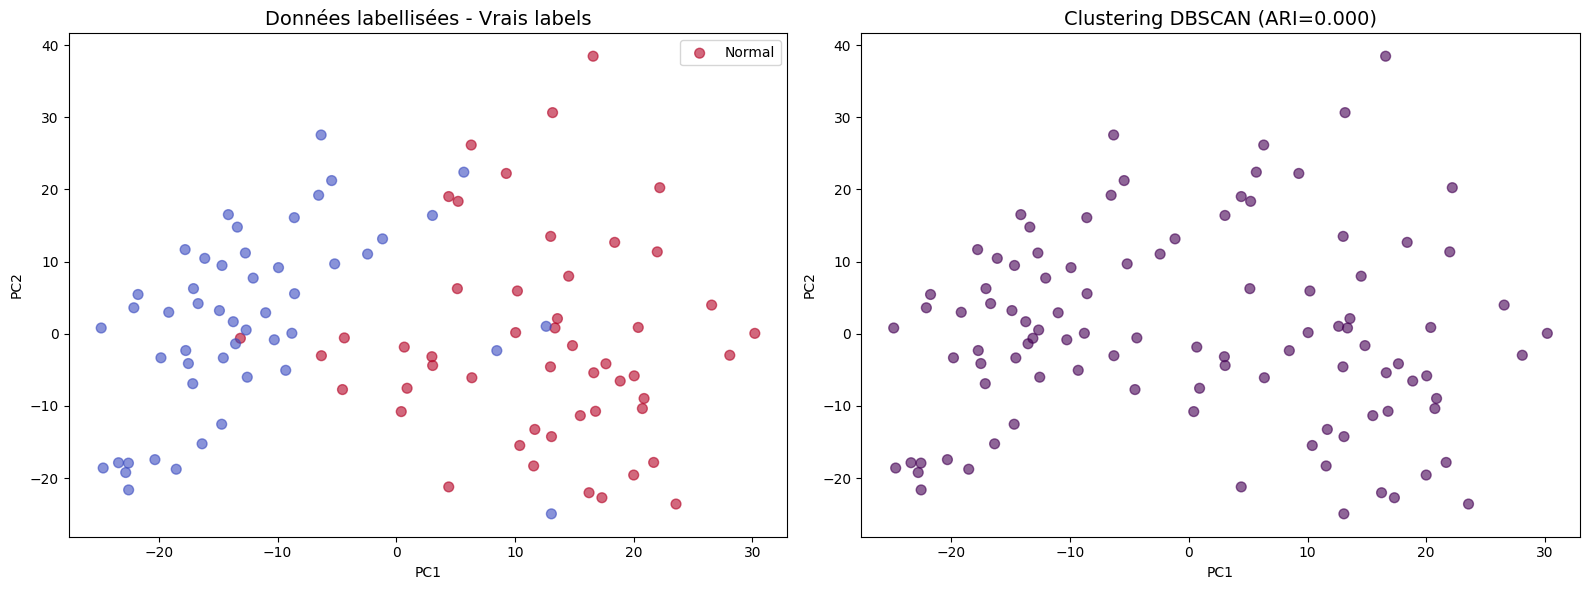

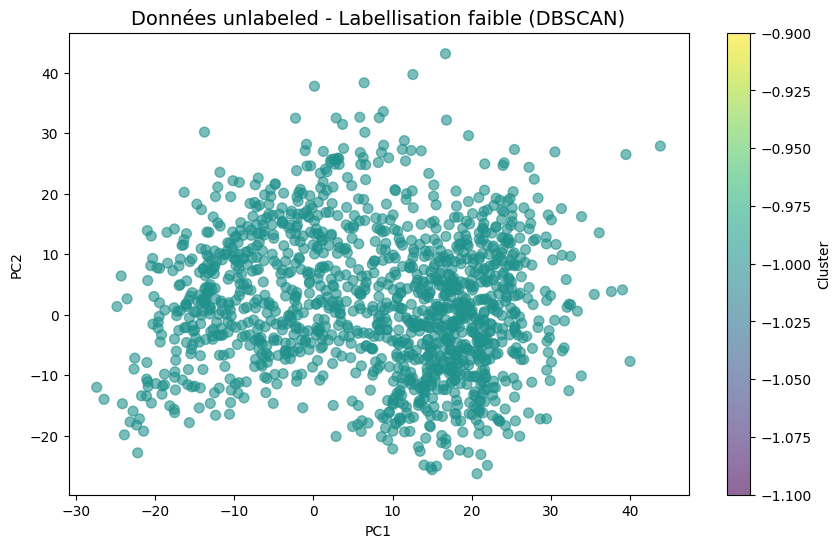

2026/01/06 10:20:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Sauvegarde des labels faibles...
✓ Labels faibles sauvegardés: weak_labels_unlabeled_dbscan.npy


2026/01/06 10:20:34 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/01/06 10:20:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/06 10:20:37 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



CLUSTERING DBSCAN TERMINÉ
ARI Score: 0.000
Variance PCA expliquée: 53.67%
Clusters labellisés: 0 (bruit: 100.0%)
Clusters unlabeled: 0 (bruit: 100.0%)
🏃 View run welcoming-cow-939 at: http://mlflow:5000/#/experiments/257703976409470419/runs/9769786e1553491ea4eaeb076afc10e5
🧪 View experiment at: http://mlflow:5000/#/experiments/257703976409470419


In [3]:
print("Chargement des features...")
features_cancer = np.load(FEATURES_DIR / "features_cancer.npy")
features_normal = np.load(FEATURES_DIR / "features_normal.npy")
features_unlabeled = np.load(FEATURES_DIR / "features_unlabeled.npy")

# Préparation des données labelisées (pour évaluation ARI)
X_labeled = np.vstack([features_cancer, features_normal])
y_true = np.array([1]*len(features_cancer) + [0]*len(features_normal))

print(f"\nDonnées labellisées: {X_labeled.shape}")
print(f"Labels: {y_true.shape}")
print(f"Données unlabeled: {features_unlabeled.shape}")

# ============================================
# PIPELINE CLUSTERING DBSCAN
# ============================================
with mlflow.start_run():
    # Log des paramètres
    mlflow.log_param("n_components_pca", N_COMPONENTS_PCA)
    mlflow.log_param("algorithm", ALGORITHM)
    mlflow.log_param("dbscan_eps", DBSCAN_EPS)
    mlflow.log_param("dbscan_min_samples", DBSCAN_MIN_SAMPLES)
    mlflow.log_param("dbscan_metric", DBSCAN_METRIC)

    # ============================================
    # 1. STANDARDISATION
    # ============================================
    print("\nStandardisation des features...")
    scaler = StandardScaler()
    X_labeled_scaled = scaler.fit_transform(X_labeled)
    X_unlabeled_scaled = scaler.transform(features_unlabeled)
    
    # ============================================
    # 2. RÉDUCTION DE DIMENSIONNALITÉ (PCA)
    # ============================================
    print("\nRéduction de dimensionnalité avec PCA...")
    pca = PCA(n_components=N_COMPONENTS_PCA)
    X_labeled_pca = pca.fit_transform(X_labeled_scaled)
    X_unlabeled_pca = pca.transform(X_unlabeled_scaled)
    
    pca_explained = pca.explained_variance_ratio_.sum()
    print(f"Variance expliquée ({N_COMPONENTS_PCA} composantes): {pca_explained:.2%}")
    mlflow.log_metric("explained_variance", pca_explained)
    
    # PCA 2D pour visualisation
    print("PCA 2D pour visualisation...")
    pca_2d = PCA(n_components=2)
    X_labeled_pca_2d = pca_2d.fit_transform(X_labeled_scaled)
    X_unlabeled_pca_2d = pca_2d.transform(X_unlabeled_scaled)
    
    # ============================================
    # 3. CLUSTERING - DBSCAN
    # ============================================
    print(f"\n=== CLUSTERING {ALGORITHM} ===")
    
    # ---- 3.1) DBSCAN sur données labellisées (pour évaluation ARI)
    print("\nClustering sur données labellisées...")
    dbscan_labeled = DBSCAN(
        eps=DBSCAN_EPS, 
        min_samples=DBSCAN_MIN_SAMPLES, 
        metric=DBSCAN_METRIC
    )
    y_pred_labeled = dbscan_labeled.fit_predict(X_labeled_pca)
    
    # Calcul ARI
    ari_score = adjusted_rand_score(y_true, y_pred_labeled)
    print(f"Score ARI (données labellisées): {ari_score:.3f}")
    mlflow.log_metric("ARI", ari_score)
    
    # Stats clusters labellisés
    unique_lab, counts_lab = np.unique(y_pred_labeled, return_counts=True)
    print(f"Répartition clusters labellisés: {dict(zip(unique_lab, counts_lab))}")
    
    n_clusters_labeled = len(set(y_pred_labeled)) - (1 if -1 in y_pred_labeled else 0)
    noise_ratio_labeled = float(np.mean(y_pred_labeled == -1))
    print(f"Nombre de clusters (hors bruit): {n_clusters_labeled}")
    print(f"Ratio de bruit: {noise_ratio_labeled:.2%}")
    
    mlflow.log_metric("n_clusters_labeled", n_clusters_labeled)
    mlflow.log_metric("noise_ratio_labeled", noise_ratio_labeled)
    
    # ---- 3.2) DBSCAN sur données unlabeled (labellisation faible)
    print("\nClustering sur données unlabeled...")
    dbscan_unlabeled = DBSCAN(
        eps=DBSCAN_EPS, 
        min_samples=DBSCAN_MIN_SAMPLES, 
        metric=DBSCAN_METRIC
    )
    y_pred_unlabeled = dbscan_unlabeled.fit_predict(X_unlabeled_pca)
    
    # Stats clusters unlabeled
    unique_unlab, counts_unlab = np.unique(y_pred_unlabeled, return_counts=True)
    print(f"Répartition clusters unlabeled: {dict(zip(unique_unlab, counts_unlab))}")
    
    n_clusters_unlabeled = len(set(y_pred_unlabeled)) - (1 if -1 in y_pred_unlabeled else 0)
    noise_ratio_unlabeled = float(np.mean(y_pred_unlabeled == -1))
    print(f"Nombre de clusters (hors bruit): {n_clusters_unlabeled}")
    print(f"Ratio de bruit: {noise_ratio_unlabeled:.2%}")
    
    mlflow.log_metric("n_clusters_unlabeled", n_clusters_unlabeled)
    mlflow.log_metric("noise_ratio_unlabeled", noise_ratio_unlabeled)
    
    # ============================================
    # 4. VISUALISATIONS + LOG MLFLOW
    # ============================================
    print("\nGénération des visualisations...")
    
    # Visualisation données labellisées
    fig_labeled = plot_labeled_comparison(
        X_labeled_pca_2d, 
        y_true, 
        y_pred_labeled, 
        ALGORITHM, 
        ari_score
    )
    mlflow.log_figure(fig_labeled, "cluster_labeled.png")
    plt.show()
    plt.close(fig_labeled)
    
    # Visualisation données unlabeled
    fig_unlabeled = plot_unlabeled_clusters(
        X_unlabeled_pca_2d, 
        y_pred_unlabeled, 
        ALGORITHM
    )
    mlflow.log_figure(fig_unlabeled, "cluster_unlabeled.png")
    plt.show()
    plt.close(fig_unlabeled)
    
    # ============================================
    # 5. SAUVEGARDE DES LABELS FAIBLES
    # ============================================
    print("\nSauvegarde des labels faibles...")
    weak_labels_filename = f"weak_labels_unlabeled_{ALGORITHM.lower()}.npy"
    np.save(FEATURES_DIR / weak_labels_filename, y_pred_unlabeled)
    print(f"✓ Labels faibles sauvegardés: {weak_labels_filename}")
    
    # ============================================
    # 6. SAUVEGARDE DU MODÈLE
    # ============================================
    # Note: DBSCAN n'a pas de méthode predict(), on sauvegarde quand même
    # pour traçabilité (mais il faudra refitter pour de nouvelles données)
    mlflow.sklearn.log_model(dbscan_labeled, "model_labeled")
    mlflow.sklearn.log_model(dbscan_unlabeled, "model_unlabeled")
    
    print("\n" + "="*50)
    print("CLUSTERING DBSCAN TERMINÉ")
    print("="*50)
    print(f"ARI Score: {ari_score:.3f}")
    print(f"Variance PCA expliquée: {pca_explained:.2%}")
    print(f"Clusters labellisés: {n_clusters_labeled} (bruit: {noise_ratio_labeled:.1%})")
    print(f"Clusters unlabeled: {n_clusters_unlabeled} (bruit: {noise_ratio_unlabeled:.1%})")